In [51]:
# Zachary Katz
# zachary_katz@mines.edu
# 24 June 2025

"""
Example notebook to load and plot daily .pos files by year.
Currently runs on example dataset with structure:
.
├── la01
│   └── 2010
│       ├── la013640_Full.pos
│       └── la013650_Full.pos
├── la02
│   ├── 2010
│   │   ├── la023640.pos
│   │   └── la023650.pos
│   └── 2011
│       ├── la020010.pos
│       └── la020020.pos
└── la05
    ├── 2010
    │   ├── la053640.pos
    │   └── la053650.pos
    └── 2011
        ├── la050010.pos
        └── la050020.pos

Any data structure arranged station then year should work    
"""

# Imports
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
from concurrent.futures import ThreadPoolExecutor
from typing import Tuple
import numpy as np
import datetime
import os

# Set path to position files
sta_path = "../../data/ExamplePos/"
# Choose stations to load
stas = ["la01", "la02", "la05"]
year_arr = ['2010','2011']

"""
Full list of stations and years for reference:
stas = ["la01", "la02", "la03", "la04", "la05", "la06", "la07", "la08", "la09",
        "la10", "la11", "la12", "la13", "la14", "la15", "la16", "la17", "la18",
        "ws04", "ws05",
        "gz01", "gz02", "gz03", "gz04", "gz05", "gz06", "gz07", "gz08", "gz09",
        "gz10", "gz11", "gz12", "gz13", "gz14", "gz15", "gz16", "gz17", "gz18",
        "gz19", "gz20",
        "mg01", "mg02", "mg03", "mg04", "mg05", "mg06", "mg07",
        "slw1"
        ]
year_arr = [["2008"],["2009"],["2010"],["2011"],["2012"],['2013'],['2014'],['2015'],["2016"],["2017"],["2018"],["2019"]]
"""

# Helper functions 
def ll2xy(lon, lat):
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y)

    Parameters
    lon - Geodetic longitude in EPSG:4326 [float]
    lat - Geodetic latitude in EPSG:4326 [float]

    Returns
    x - Antarctic Polar Stereographic (EPSG:3031) x [float]
    y - Antarctic Polar Stereographic (EPSG:3031) y [float]
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y
    

In [ ]:
# Datastream class
# This probably should be in a separate file

class Datastream:
    """Data for one station"""

    def __init__(
        self, sta: os.DirEntry, name: str, years: list) -> None:
        """Initialize a data stream.

        Parameters
        ----------
        sta: os.DirEntry
            Path to station
        name : str
            Name of the station (Typically the directory name)
        years : list
            List of year folders to include in this data stream.
        """
        self.sta = sta
        self.name = name
        self.years = years

        data = self.make_data_stream(sta, years)
        self.data = data

    def make_data_stream(self, sta: os.DirEntry, years: list) -> pd.DataFrame:
        """
        Return a Pandas data frame for all .pos files in years.

        Takes input directory sta with year subdirectories containing .pos files.
        Starting from the first file in the first year, append days until all files
        in the directory have been added.

        Parameters
        ----------
        dir: os.DirEntry
            Input directory tree with structure described in top comment [string]
        years: list of strings
            Years to be run

        Returns
        data: pd.DataFrame
            Multi-day data frame
        """

        data = pd.DataFrame()
        for year in years:
            for folder in os.scandir(os.fspath(self.sta)):
                # Folder is an os.DirEntry object
                if folder.is_dir():
                    if folder.name == year:
                        for gps in sorted(os.listdir(folder.path)):
                            # Ignore xyzt, zip files
                            if gps.endswith(".pos") and not gps.startswith("."):
                                ind_data, flip = self.load(f"{folder.path}/{gps}")
                                # Reorder the data if using CSRS-PPP 2024 pre 2018
                                if flip:
                                    ind_data = ind_data.reindex(
                                        index=ind_data.index[::-1]
                                    )
                                data = pd.concat([data, ind_data], ignore_index=True)
        return data

    def load(self, file: str) -> Tuple[pd.DataFrame, bool]:
        """
        Load processed gps data file into pandas table.

        Assumes data at 00,15,30,45 second intervals and removes all other data.
        For slw1, 46 second data are moved to 45 seconds.


        Parameters
        file - .pos precise point solution file, Natural Resources Canada [string]

        Returns
        data - Pandas DataFrame with the following columns, extracted from file
            longitude - Geodetic longitude
            latitude - Geodetic latitude
            elevation - Elevation
            time - Time as datetime object
            day_of_year - Time as julian day
            x - Antarctic Polar Stereographic x
            y - Antarctic Polar Stereographic y
            dist - Euclidian distance from starting position in meters
        flip - flag to flip order of readings for 2024 csrs-ppp data
        """

        data = pd.DataFrame()  # Create Pandas DataFrame
        flip = False
        # Read data file

        # Convert longitude and latitude from deg min sec to fractional degrees
        # Three different possible file formats so try one first and try the other if it
        # throws a not found exception.
        try:
            # CSRS-PPP 2024
            d = pd.read_csv(
                file, skiprows=3, sep="\\s+"
            )  # delim_whitespace=True depreciated, used \\s+ instead
            # Only take 15 or 30 sec intervals if data is finer spaced
            d = d.loc[
                d["HR:MN:SS.SS"].str.endswith("00.00")
                | d["HR:MN:SS.SS"].str.endswith("15.00")
                | d["HR:MN:SS.SS"].str.endswith("30.00")
                | d["HR:MN:SS.SS"].str.endswith("45.00")
                | d["HR:MN:SS.SS"].str.endswith("16.00")  # Slw1 only, move to 15 sec
                | d["HR:MN:SS.SS"].str.endswith("46.00")  # Slw1 only, move to 45 sec
            ]
            data["longitude"] = d["LONDD"] - d["LONMN"] / 60 - d["LONSS"] / 60 / 60
            data["latitude"] = d["LATDD"] - d["LATMN"] / 60 - d["LATSS"] / 60 / 60
            data["time"] = pd.to_datetime(d["YEAR-MM-DD"] + "T" + d["HR:MN:SS.SS"])
            data.loc[data["time"].dt.second == 46, "time"] = data[
                "time"
            ] - pd.Timedelta(seconds=1)  # Slw1 only, move to 45 sec
            data.loc[data["time"].dt.second == 16, "time"] = data[
                "time"
            ] - pd.Timedelta(seconds=1)  # Slw1 only, move to 15 sec
            data["day_of_year"] = d["DAYofYEAR"]

        # If not in 2024 format, may be in an older format, tested for below...
        except Exception as e:
            try:
                d = pd.read_csv(file, skiprows=7, sep="\\s+")
                data["longitude"] = (
                    d["LON(d)"] - d["LON(m)"] / 60 - d["LON(s)"] / 60 / 60
                )
                data["latitude"] = (
                    d["LAT(d)"] - d["LAT(m)"] / 60 - d["LAT(s)"] / 60 / 60
                )
                data["time"] = pd.to_datetime(d["YEAR-MM-DD"] + "T" + d["HR:MN:SS.SSS"])
                data["day_of_year"] = d["DOY"]
            except Exception as e:
                try:
                    d = pd.read_csv(file, skiprows=5, sep="\\s+")
                    data["longitude"] = (
                        d["LONDD"] - d["LONMN"] / 60 - d["LONSS"] / 60 / 60
                    )
                    data["latitude"] = (
                        d["LATDD"] - d["LATMN"] / 60 - d["LATSS"] / 60 / 60
                    )
                    data["time"] = pd.to_datetime(
                        d["YEAR-MM-DD"] + "T" + d["HR:MN:SS.SS"]
                    )
                    data["day_of_year"] = d["DAYofYEAR"]
                except Exception as e:
                    d = pd.read_csv(file, skiprows=6, sep="\\s+")
                    data["longitude"] = (
                        d["LON(d)"] - d["LON(m)"] / 60 - d["LON(s)"] / 60 / 60
                    )
                    data["latitude"] = (
                        d["LAT(d)"] - d["LAT(m)"] / 60 - d["LAT(s)"] / 60 / 60
                    )
                    data["time"] = pd.to_datetime(
                        d["YEAR-MM-DD"] + "T" + d["HR:MN:SS.SSS"]
                    )
                    data["day_of_year"] = d["DOY"]

        data["elevation"] = d["HGT(m)"]
        data["sats"] = d["NSV"]
        data["GDOP"] = d["GDOP"]

        # Convert to Antarctic Polar Stereographic
        x, y = ll2xy(lon=data["longitude"], lat=data["latitude"])
        data["x"] = x
        data["y"] = y

        # Look at data and decide if to flip
        if len(data.index) > 1:
            diff = data["time"].iloc[0] - data["time"].iloc[1]
            if diff > datetime.timedelta(seconds=0):
                flip = True

            x0 = data["x"].iloc[0]
            y0 = data["y"].iloc[0]

            data["dist"] = np.sqrt((data["x"] - x0) ** 2 + (data["y"] - y0) ** 2)

        return data, flip

In [52]:
def load_station(sta: str, years: list, directory: str) -> Datastream:
    """
    Load a station's worth of data for the years specified.
 
    Parameters
    ----------
    sta: str
        Station name
    years : list
        List of year folders to include in this data stream.

    returns
    -------
    Datastream
    Datastream object containing the data in the position file
    """
    cat = Datastream(os.path.join(directory, sta), sta, years)
    return cat

# Load stations in parallel
with ThreadPoolExecutor() as executor:
    results = executor.map(load_station, stas, [year_arr] * len(stas), [sta_path] * len(stas))

cats = [cat for cat in results if cat is not None]



0       2010-12-30 00:00:00
1       2010-12-30 00:00:15
2       2010-12-30 00:00:30
3       2010-12-30 00:00:45
4       2010-12-30 00:01:00
                ...        
11515   2010-12-31 23:58:45
11516   2010-12-31 23:59:00
11517   2010-12-31 23:59:15
11518   2010-12-31 23:59:30
11519   2010-12-31 23:59:45
Name: time, Length: 11520, dtype: datetime64[ns]
0       2010-12-30 00:00:00
1       2010-12-30 00:00:30
2       2010-12-30 00:01:00
3       2010-12-30 00:01:30
4       2010-12-30 00:02:00
                ...        
11515   2011-01-02 23:57:30
11516   2011-01-02 23:58:00
11517   2011-01-02 23:58:30
11518   2011-01-02 23:59:00
11519   2011-01-02 23:59:30
Name: time, Length: 11520, dtype: datetime64[ns]
0       2010-12-30 00:00:00
1       2010-12-30 00:00:15
2       2010-12-30 00:00:30
3       2010-12-30 00:00:45
4       2010-12-30 00:01:00
                ...        
23035   2011-01-02 23:58:45
23036   2011-01-02 23:59:00
23037   2011-01-02 23:59:15
23038   2011-01-02 23:59:30
23039 

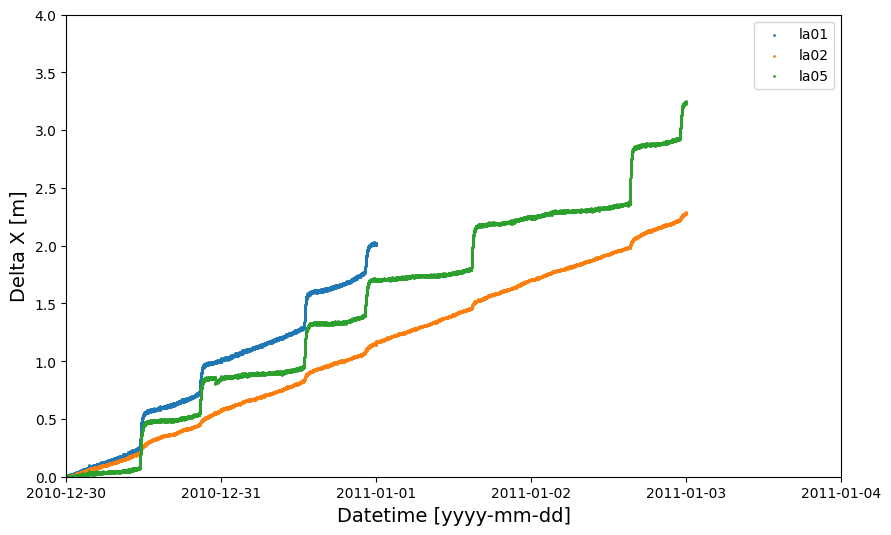

In [58]:
# Plot
fig, ax = plt.subplots(figsize=(10,6))
for cat in cats:
    times = pd.to_datetime(cat.data["time"])
    print(times)
    ax.scatter(times,cat.data['x'] - cat.data['x'].iloc[0], label=cat.name,s=1)
ax.set_xlim(pd.to_datetime("2010-12-30"), pd.to_datetime("2011-01-04"))
ax.set_ylim(0,4)
ax.set_xlabel("Datetime [yyyy-mm-dd]", fontsize=14)
ax.set_ylabel("Delta X [m]", fontsize=14)
ax.legend()